<a href="https://colab.research.google.com/github/rehabib/SPARK-2025/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.mount("content")

Mounted at content


In [4]:
hos_ops = pd.read_csv("/content/content/MyDrive/03_hospital_ops.csv")

Exploring the data before starting the project

In [5]:
hos_ops.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   department        240 non-null    object 
 1   date              240 non-null    object 
 2   patients_seen     240 non-null    int64  
 3   avg_wait_min      240 non-null    float64
 4   beds_occupied     240 non-null    int64  
 5   total_beds        240 non-null    int64  
 6   scans_done        240 non-null    int64  
 7   utilisation_rate  240 non-null    float64
dtypes: float64(2), int64(4), object(2)
memory usage: 15.1+ KB


In [6]:
hos_ops.describe()

,patients_seen,avg_wait_min,beds_occupied,total_beds,scans_done,utilisation_rate
count,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000
mean,33.912500,97.062917,20.750000,44.979167,11.191667,0.689833
std,15.345009,48.476985,9.919551,3.243852,5.394551,0.176581
min,8.000000,15.600000,5.000000,40.000000,2.000000,0.400000
25%,20.750000,53.475000,12.000000,42.000000,7.000000,0.540000
50%,33.000000,97.200000,19.500000,45.000000,11.500000,0.680000
75%,48.000000,137.400000,29.000000,48.000000,15.000000,0.850000
max,60.000000,179.400000,40.000000,50.000000,20.000000,1.000000


In [7]:
hos_ops.head()


,department,date,patients_seen,avg_wait_min,beds_occupied,total_beds,scans_done,utilisation_rate
0,Emergency,2024-03-01,40,125.6,23,49,9,0.82
1,Emergency,2024-03-02,10,90.8,15,44,16,0.40
2,Emergency,2024-03-03,31,173.7,40,45,9,0.42
3,Emergency,2024-03-04,27,50.9,16,40,12,0.63
4,Emergency,2024-03-05,38,61.0,17,43,18,0.87


In [8]:
hos_ops.tail()

,department,date,patients_seen,avg_wait_min,beds_occupied,total_beds,scans_done,utilisation_rate
235,ICU,2024-03-26,43,132.2,24,42,15,0.42
236,ICU,2024-03-27,9,86.1,8,47,20,0.71
237,ICU,2024-03-28,60,34.6,31,49,14,0.67
238,ICU,2024-03-29,8,127.2,14,47,15,0.73
239,ICU,2024-03-30,13,121.3,18,42,2,0.66


In [9]:
hos_ops[hos_ops['department'] == "ICU"]

,department,date,patients_seen,avg_wait_min,beds_occupied,total_beds,scans_done,utilisation_rate
210,ICU,2024-03-01,44,164.5,13,48,13,0.78
211,ICU,2024-03-02,8,123.5,18,41,11,0.55
212,ICU,2024-03-03,14,110.5,19,42,16,0.61
213,ICU,2024-03-04,17,49.4,30,48,7,0.77
214,ICU,2024-03-05,52,115.4,10,50,19,0.87
215,ICU,2024-03-06,27,47.6,18,48,4,0.85
216,ICU,2024-03-07,36,125.8,12,48,5,0.56
217,ICU,2024-03-08,22,151.5,35,47,19,0.44
218,ICU,2024-03-09,37,164.4,36,43,17,0.50
219,ICU,2024-03-10,46,157.4,5,42,12,0.68


In [10]:
hos_ops[hos_ops['department'].isin(["ICU", ])]

,department,date,patients_seen,avg_wait_min,beds_occupied,total_beds,scans_done,utilisation_rate
210,ICU,2024-03-01,44,164.5,13,48,13,0.78
211,ICU,2024-03-02,8,123.5,18,41,11,0.55
212,ICU,2024-03-03,14,110.5,19,42,16,0.61
213,ICU,2024-03-04,17,49.4,30,48,7,0.77
214,ICU,2024-03-05,52,115.4,10,50,19,0.87
215,ICU,2024-03-06,27,47.6,18,48,4,0.85
216,ICU,2024-03-07,36,125.8,12,48,5,0.56
217,ICU,2024-03-08,22,151.5,35,47,19,0.44
218,ICU,2024-03-09,37,164.4,36,43,17,0.50
219,ICU,2024-03-10,46,157.4,5,42,12,0.68


In [11]:
hos_ops.columns

Index(['department', 'date', 'patients_seen', 'avg_wait_min', 'beds_occupied',
       'total_beds', 'scans_done', 'utilisation_rate'],
      dtype='object')

In [ ]:
# Missing values count per column
hos_ops.isnull().sum()


,0
department,0
date,0
patients_seen,0
avg_wait_min,0
beds_occupied,0
total_beds,0
scans_done,0
utilisation_rate,0


In [13]:
# Check data types
hos_ops.dtypes
# Convert date column
hos_ops['date'] = pd.to_datetime(hos_ops['date'], errors='coerce')

In [ ]:

# Convert numeric columns (replace with your real column names)
numeric_cols = ['avg_wait_min', 'beds_occupied', 'scans_done']
for col in numeric_cols:
    hos_ops[col] = pd.to_numeric(hos_ops[col], errors='coerce')

# Convert categorical columns to category type
hos_ops['department'] = hos_ops['department'].astype('category')

In [ ]:
# Count duplicates
hos_ops.duplicated().sum()

np.int64(0)

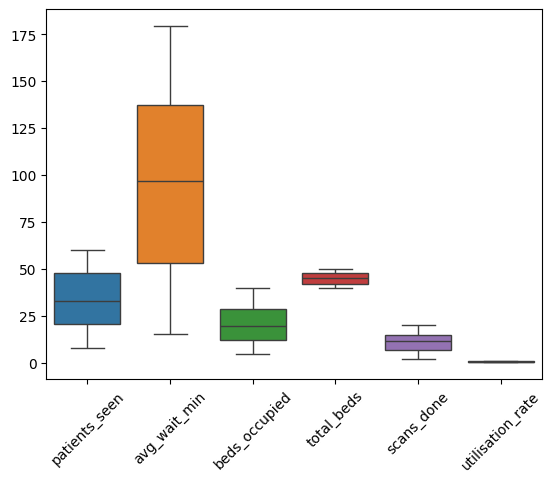

In [ ]:
#to check outliers
sns.boxplot(data=hos_ops[['patients_seen', 'avg_wait_min', 'beds_occupied',
                          'total_beds', 'scans_done', 'utilisation_rate']])
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Negative patient counts?
hos_ops[hos_ops['patients_seen'] < 0]

# Wait times too extreme?
hos_ops[hos_ops['avg_wait_min'] > hos_ops['avg_wait_min'].quantile(0.99)]

# Beds occupied cannot exceed total beds:
hos_ops[hos_ops['beds_occupied'] > hos_ops['total_beds']]

# Negative scans?
hos_ops[hos_ops['scans_done'] < 0]

# utilisation_rate should be between 0 and 1 or between 0 and 100 (depending on your data)
hos_ops[(hos_ops['utilisation_rate'] < 0) | (hos_ops['utilisation_rate'] > 100)]

,department,date,patients_seen,avg_wait_min,beds_occupied,total_beds,scans_done,utilisation_rate


In [ ]:
hos_ops['department'].unique()

['Emergency', 'Radiology', 'Cardiology', 'Paediatrics', 'Surgery', 'Maternity', 'Outpatient', 'ICU']
Categories (8, object): ['Cardiology', 'Emergency', 'ICU', 'Maternity', 'Outpatient', 'Paediatrics',
                         'Radiology', 'Surgery']

In [ ]:
hos_ops['department'].value_counts()

,count
department,
Cardiology,30
Emergency,30
ICU,30
Maternity,30
Outpatient,30
Paediatrics,30
Radiology,30
Surgery,30


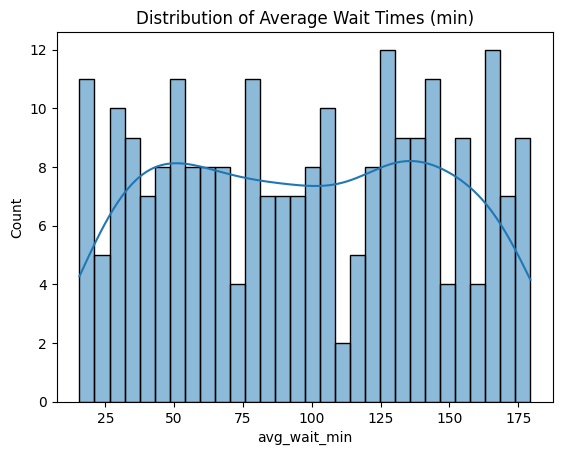

In [ ]:
sns.histplot(hos_ops['avg_wait_min'], bins=30, kde=True)
plt.title("Distribution of Average Wait Times (min)")
plt.show()

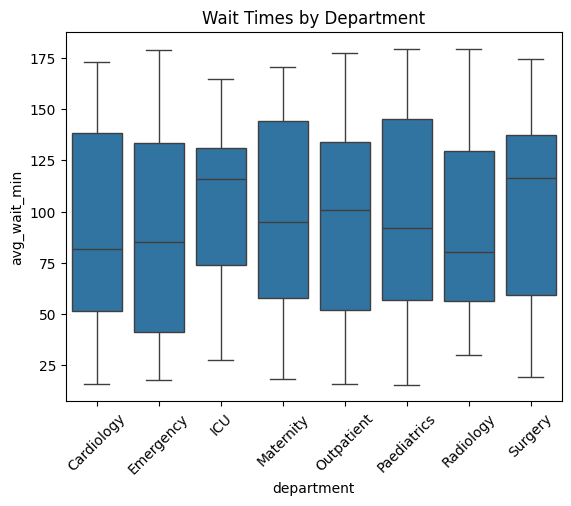

In [ ]:
sns.boxplot(x='department', y='avg_wait_min', data=hos_ops)
plt.xticks(rotation=45)
plt.title("Wait Times by Department")
plt.show()

/tmp/ipykernel_511/4215072829.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = hos_ops.pivot_table(


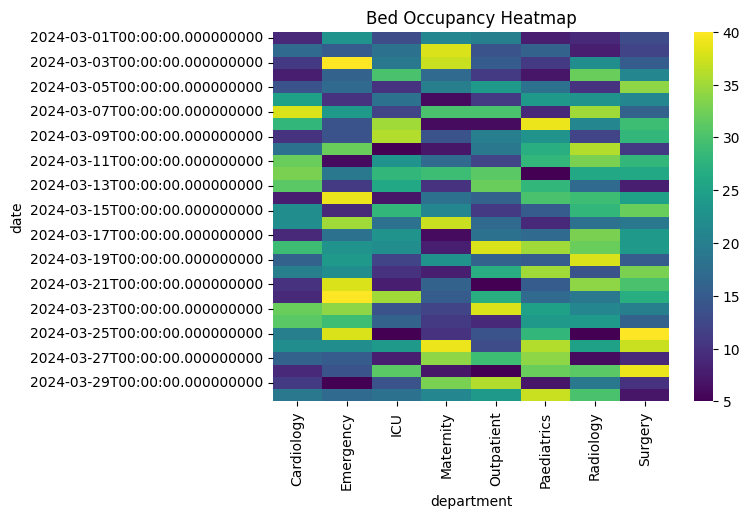

In [ ]:
pivot = hos_ops.pivot_table(
    index='date',
    columns='department',
    values='beds_occupied'
)

sns.heatmap(pivot, cmap="viridis")
plt.title("Bed Occupancy Heatmap")
plt.show()

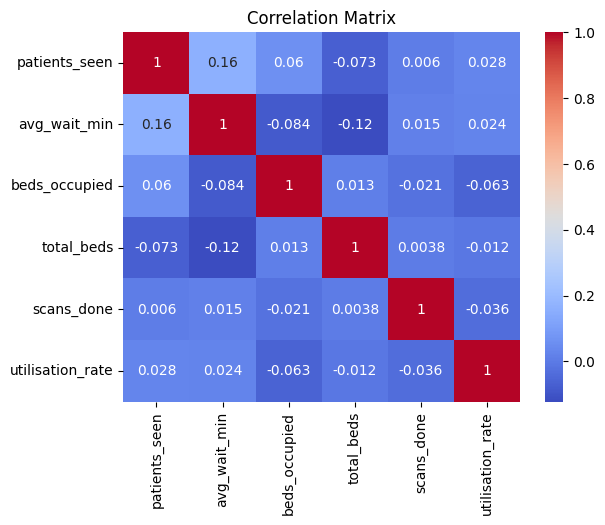

In [ ]:
corr = hos_ops.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
hos_ops['day'] = hos_ops['date'].dt.day

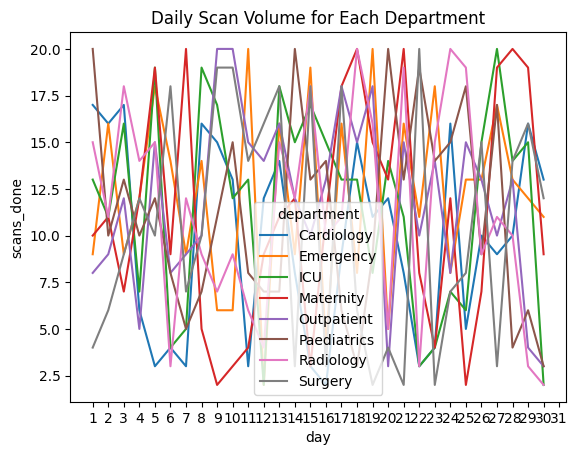

In [ ]:
sns.lineplot(
    data=hos_ops,
    x='day',
    y='scans_done',
    hue='department'
)
plt.title("Daily Scan Volume for Each Department")
plt.xticks(range(1, 32))
plt.show()

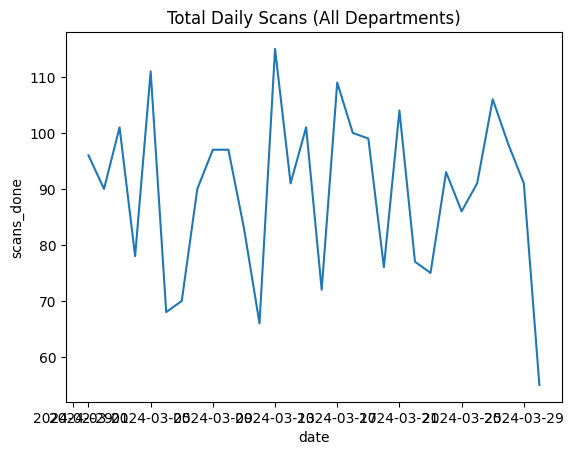

In [ ]:
daily_scans = hos_ops.groupby('date')['scans_done'].sum().reset_index()

sns.lineplot(data=daily_scans, x='date', y='scans_done')
plt.title("Total Daily Scans (All Departments)")
plt.show()

In [15]:
# Ensure date is sorted
hos_ops = hos_ops.sort_values('date')

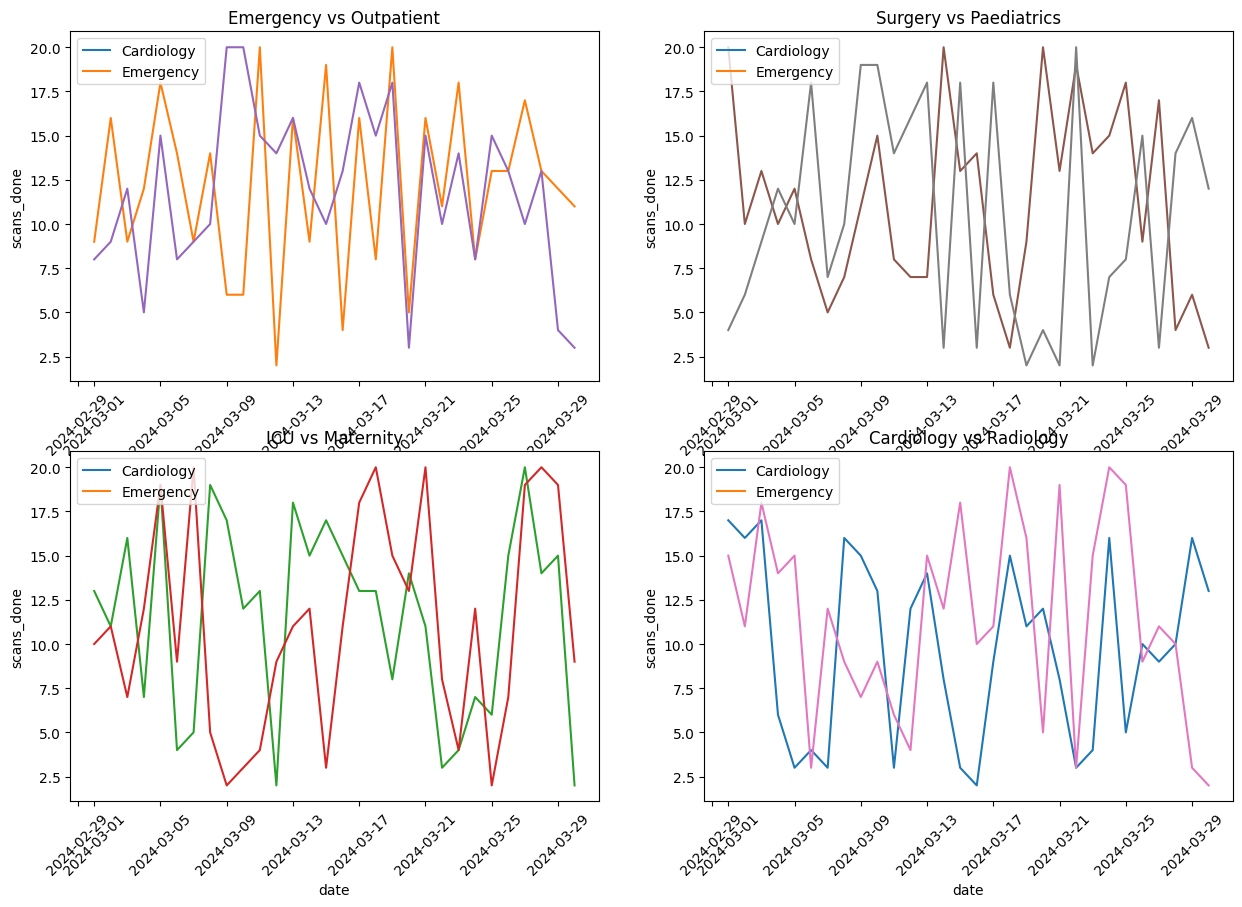

In [ ]:

# Ensure date is sorted
hos_ops = hos_ops.sort_values('date')

# Get departments
departments = hos_ops['department'].unique();

# Split into groups of 2
groups = [departments[i:i+2] for i in range(0, len(departments), 2)]

# Create subplots (2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes = axes.flatten()  # makes indexing easier

for i, group in enumerate(groups):
    subset = hos_ops[hos_ops['department'].isin(group)]

    sns.lineplot(
        data=subset,
        x='date',
        y='scans_done',
        hue='department',
        ax=axes[i]
    )

    axes[i].set_title(f"{group[0]} vs {group[1]}")
    axes[i].tick_params(axis='x', rotation=45)

    # Fix legend
    handles, labels = axes[i].get_legend_handles_labels()
    axes[i].legend(handles=handles[:len(group)], labels=labels[:len(group)], loc='upper left')
plt.show()

building the oop structure

In [16]:
#creating department and hospital class
#building department class
class Department:
  def __init__(self,name, hos_ops):
    self.name = name
    self.hos_ops = hos_ops[hos_ops['department'] == name].copy()

  def avg_wait_min(self):
    return self.hos_ops['avg_wait_min'].mean()

  def occupancy_rate(self):
        return (self.df['beds_occupied'] / self.df['total_beds']).mean()


  def scan_utilisation(self):
        # If utilisation_rate column exists, use it directly
        if 'utilisation_rate' in self.df.columns:
            return self.df['utilisation_rate'].mean()
        else:
            return self.df['scans_done'].sum()

  def daily_scans(self):
        return self.df.groupby('date')['scans_done'].sum()
#building hospital class

class Hospital:
  def __init__(self, hos_ops):
    self.hos_ops = hos_ops
    self.departments = {}

    dept_names = hos_ops['department'].unique()
    for name in dept_names:
      self.departments[name] = Department(name, hos_ops)

  def overall_avg_wait(self):
        return self.df['avg_wait_min'].mean()

  def overall_occupancy(self):
        return (self.df['beds_occupied'] / self.df['total_beds']).mean()

  def overall_scans(self):
        return self.df['scans_done'].sum()

  def get_department(self, name):
        return self.departments.get(name)

In [17]:
#let us write using dry concept

class BaseKPI:
    def avg_wait_min(self):
        return self.hos_ops['avg_wait_min'].mean()

    def occupancy_rate(self):
        return (self.hos_ops['beds_occupied'] / self.hos_ops['total_beds']).mean()

    def scan_utilisation(self):
        if 'utilisation_rate' in self.hos_ops.columns:
            return self.hos_ops['utilisation_rate'].mean()
        return self.hos_ops['scans_done'].sum()




In [18]:
class Department(BaseKPI):
    def __init__(self, name, hos_ops):
        self.name = name
        self.hos_ops = hos_ops[hos_ops['department'] == name].copy()

    def daily_scans(self):
        return self.hos_ops.groupby('date')['scans_done'].sum()

In [19]:
class Hospital(BaseKPI):
    def __init__(self, hos_ops):
        self.hos_ops = hos_ops

        # Create department objects for each unique department
        self.departments = {
            name: Department(name, hos_ops)
            for name in hos_ops['department'].unique()
        }

    def get_department(self, name):
        return self.departments.get(name)

In [24]:
#load the file using load_data() function
def load_data(path):
    hos_ops = pd.read_csv(path)

    # Clean and convert
    hos_ops['date'] = pd.to_datetime(hos_ops['date'])
    hos_ops = hos_ops.sort_values('date')

    return hos_ops